In [1]:
import pandas as pd

In [2]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys

print(sys.executable)

c:\Program Files\Python314\python.exe


In [3]:
import sys
!{sys.executable} -m pip install matplotlib

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import matplotlib.pyplot as plt
df = pd.read_csv("ECOMM_cleaned.csv")

df.head()

,ROW ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Shipping Cost,Profit,Order Priority
0,26341,CA-2012-124891,31/7/2012,31/7/2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,933.57,762.1845,Critical
1,26341,IN-2013-77878,5/2/2013,7/2/2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,923.63,-288.7650,Critical
2,25330,IN-2013-71249,17/10/2013,18/10/2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,915.49,919.9710,Medium
3,13524,ES-2013-1579342,28/1/2013,30/1/2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,910.16,-96.5400,Medium
4,47221,SG-2013-4320,5/11/2013,6/11/2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,903.04,311.5200,Critical


In [8]:
print(df.shape)

(51290, 24)


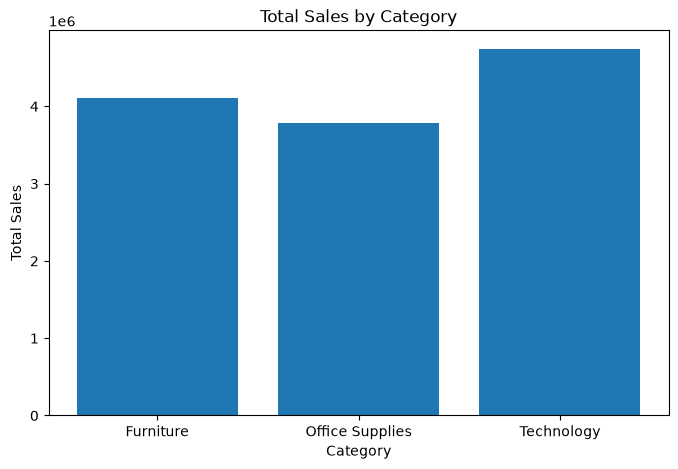

In [ ]:
###SALES BY CATEGORY - BAR CHART
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

C:\Users\rashi\AppData\Local\Temp\ipykernel_6020\13081262.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [13]:
print(df["Order Date"].dtype)

datetime64[us]


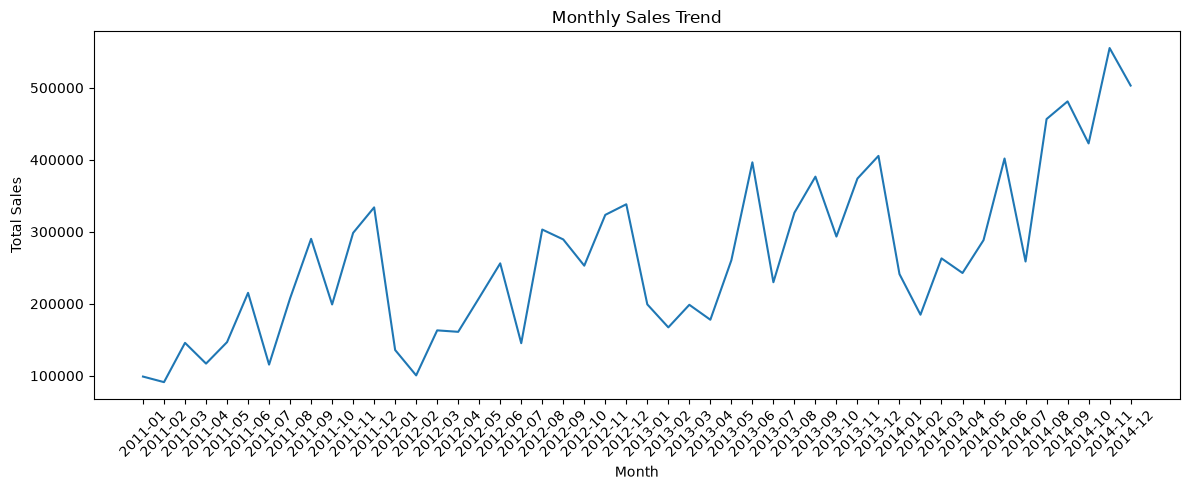

In [ ]:
### MONTHLY SALES TREND - LINE CHART 
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



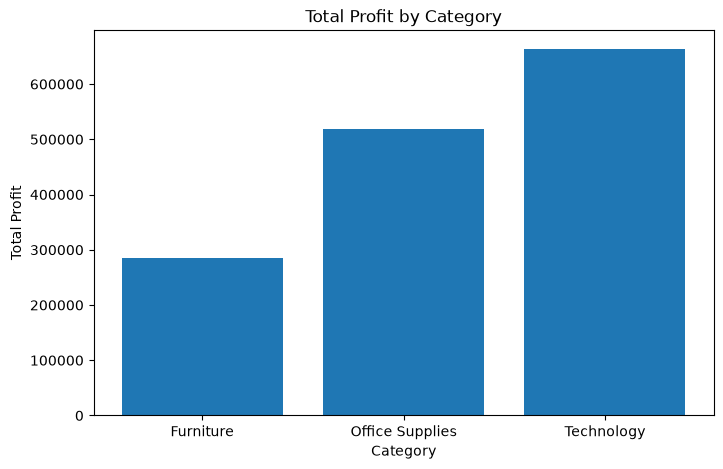

In [ ]:
###PROFIT BY CATEGORY - BAR CHART 
profit_category = df.groupby("Category")["Profit"].sum()
plt.figure(figsize=(8, 5))
plt.bar(profit_category.index, profit_category.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

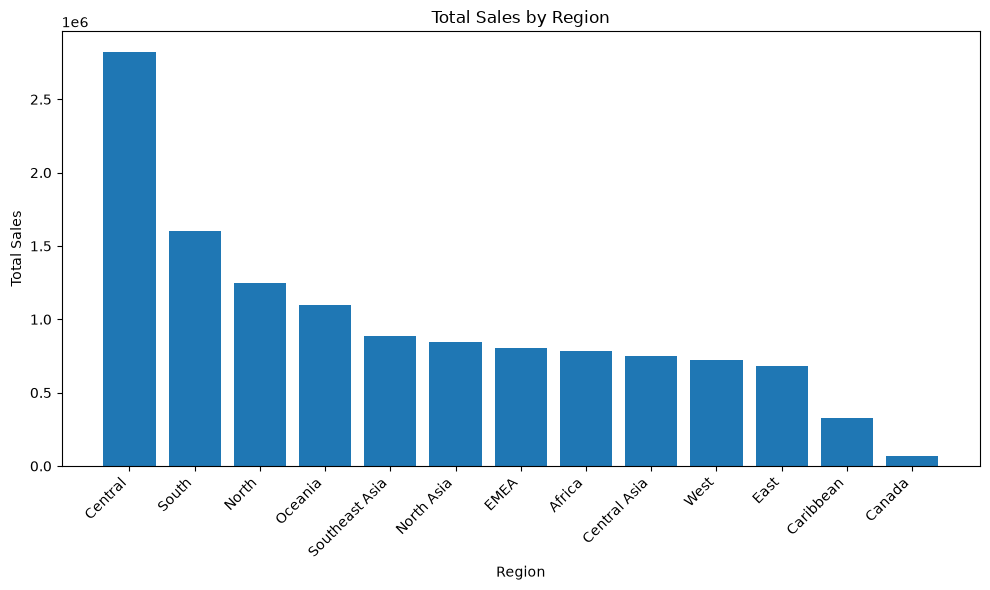

In [ ]:
###SALES BY REGION - BAR CHART 
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

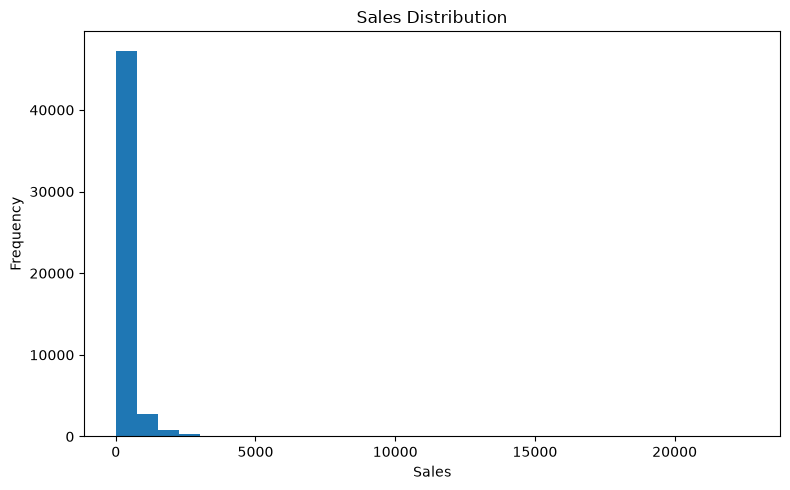

In [ ]:
###SALES DISTRIBUTIOB  - HISTOGRAM
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

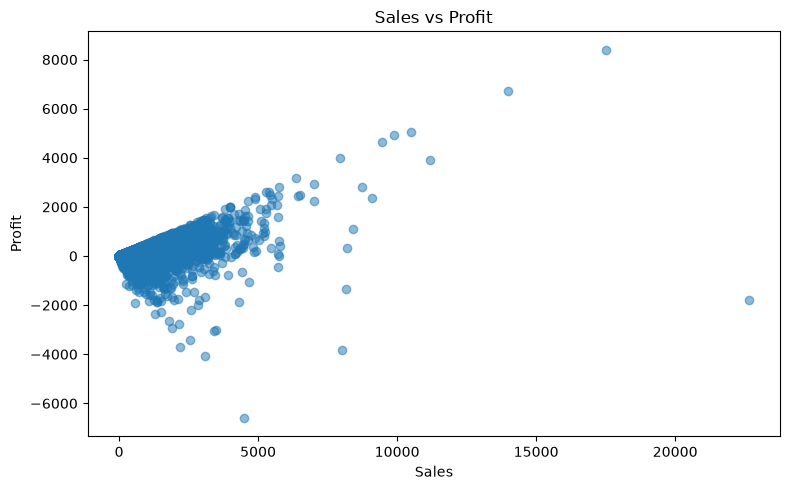

In [ ]:
###SALES VS PROFIT - SCATTER PLOT
plt.figure(figsize=(8, 5))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

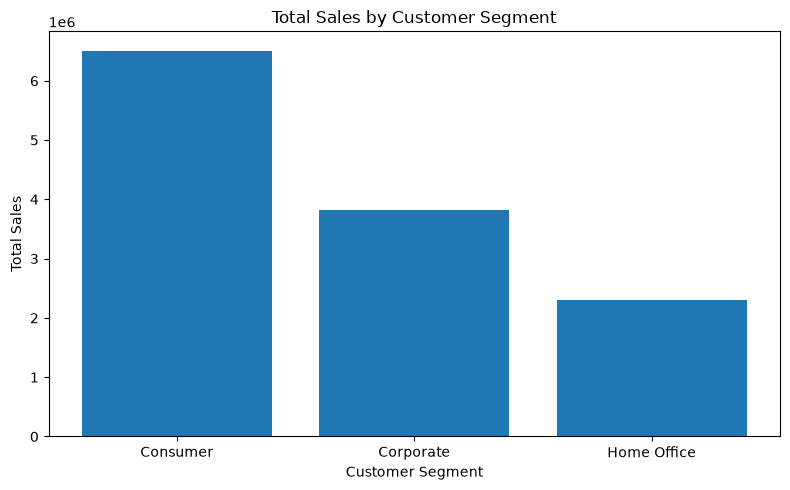

In [ ]:
###SALES BY CUSTOMER SEGMENTS - BAR CHARTS 
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(segment_sales.index, segment_sales.values)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

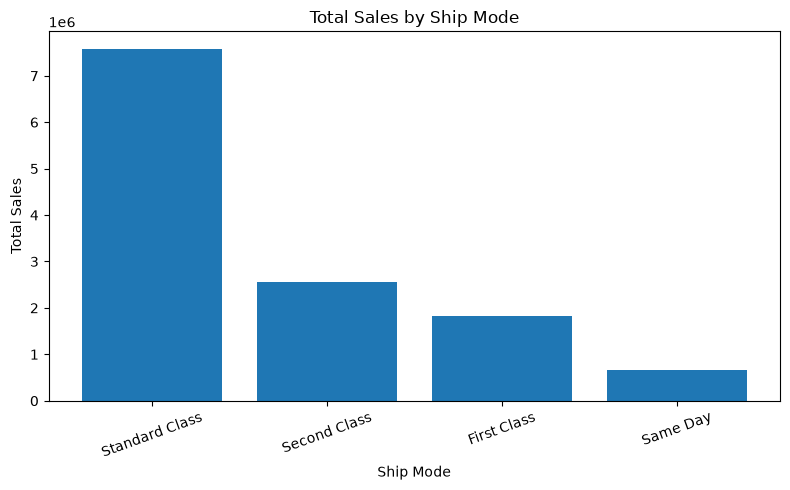

In [ ]:
###SALES BY SHIP MODE - BAR CHART 
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(ship_sales.index, ship_sales.values)

plt.title("Total Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

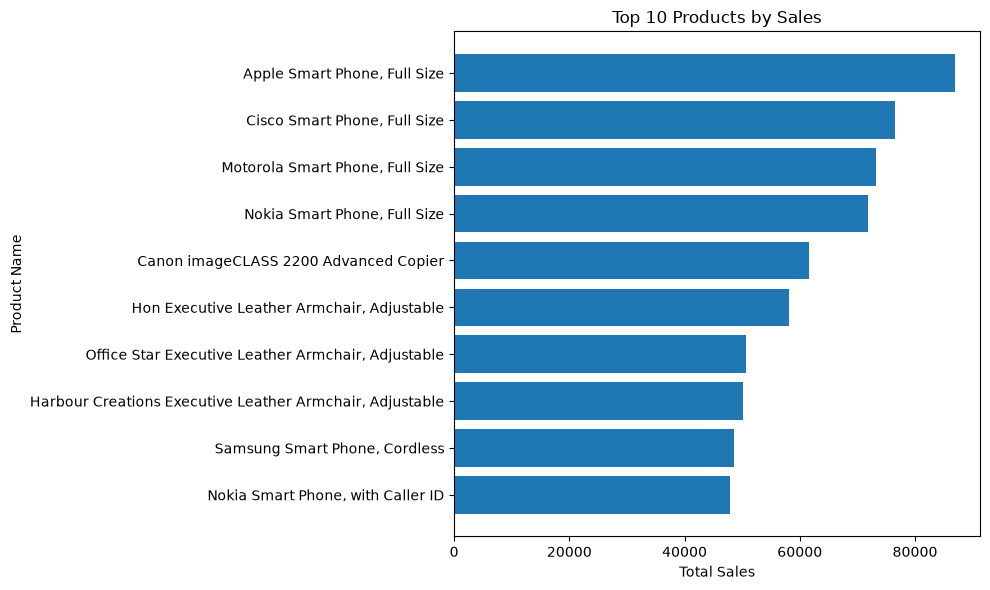

In [ ]:
###TOP 10 PRODUCT BY SALE - BAR CHART 
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_products.index[::-1], top_products.values[::-1])

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

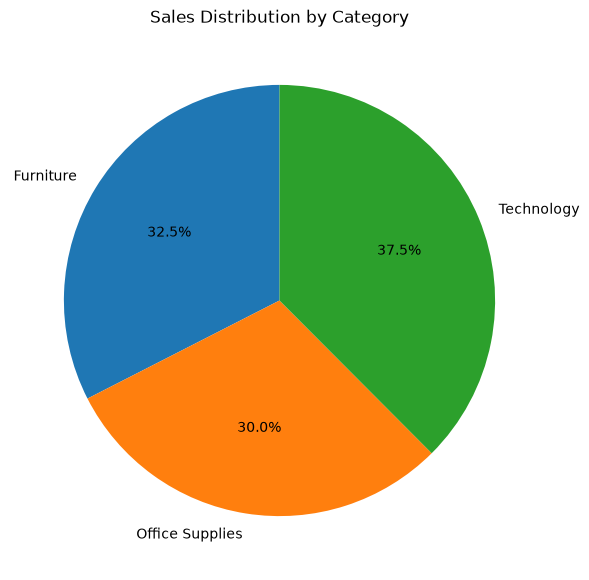

In [ ]:
###SALES DISTRIBUTION BY CATEGORY - PIE CHART 
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7, 7))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Category")

plt.show()

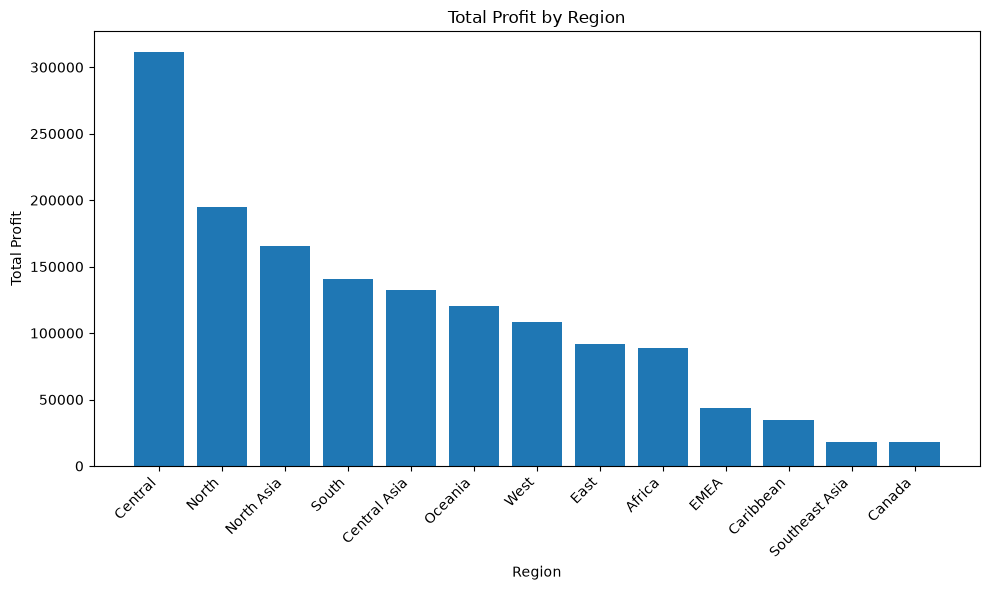

In [ ]:
###PROFIT BY REGION - BAR CHART 
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(region_profit.index, region_profit.values)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

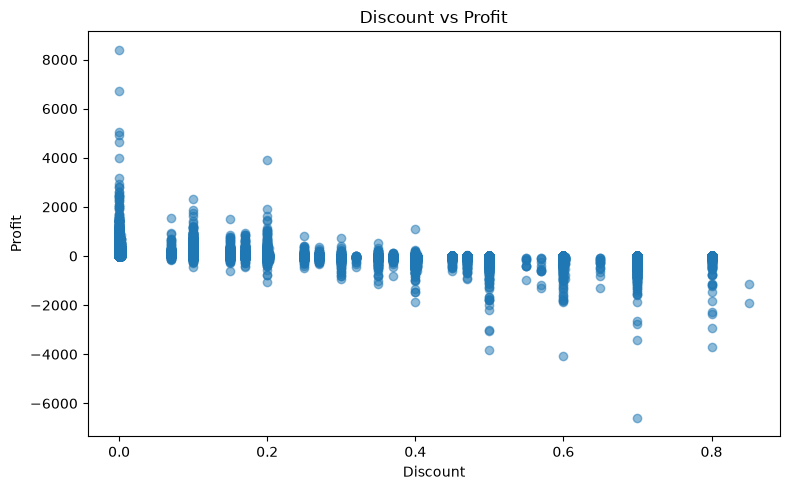

In [ ]:
### DISCOUNT VS PROFIT - SCATTER PLOT
plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

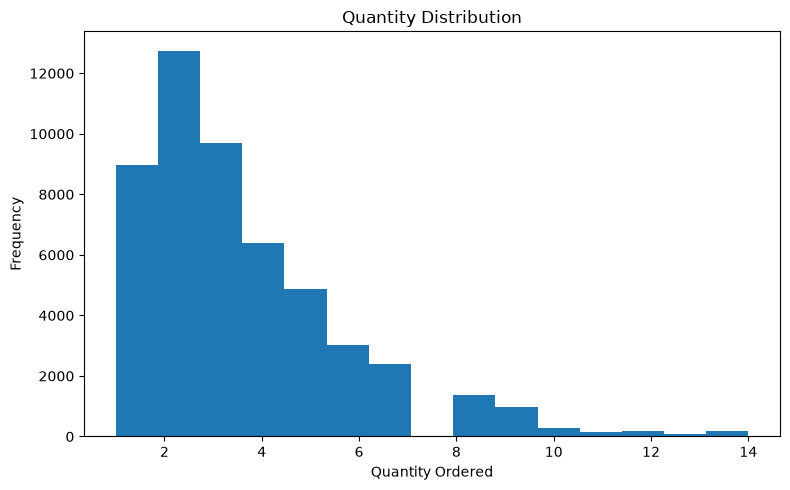

In [ ]:
###QUANTITY DISTRIBUTION - HISTOGRAM
plt.figure(figsize=(8, 5))
plt.hist(df["Quantity"], bins=15)

plt.title("Quantity Distribution")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

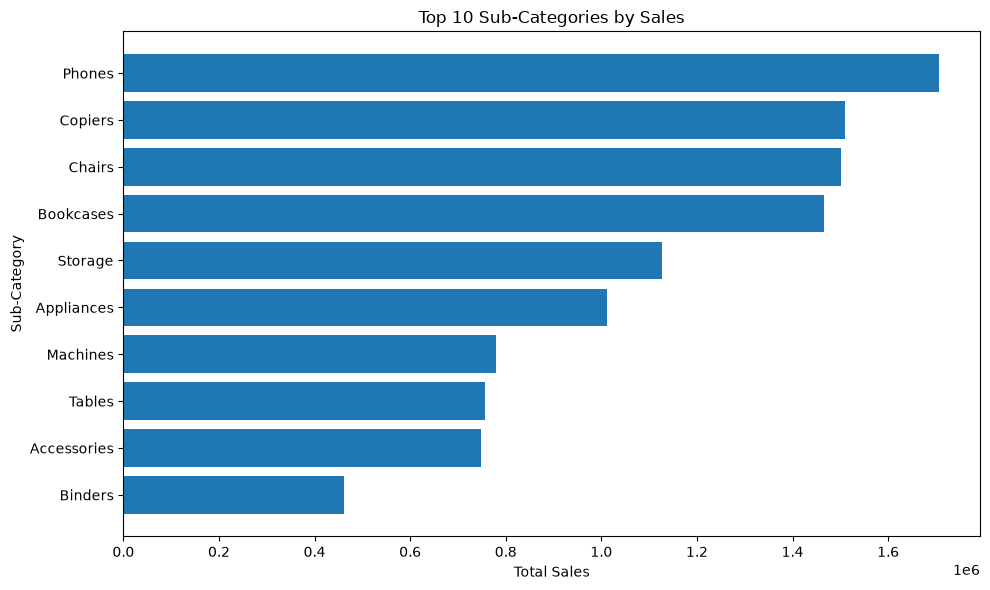

In [ ]:
### TOP 10 SUB-CTAEGORY BY SALE - BAR CHART 
top_subcategories = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_subcategories.index[::-1],
    top_subcategories.values[::-1]
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

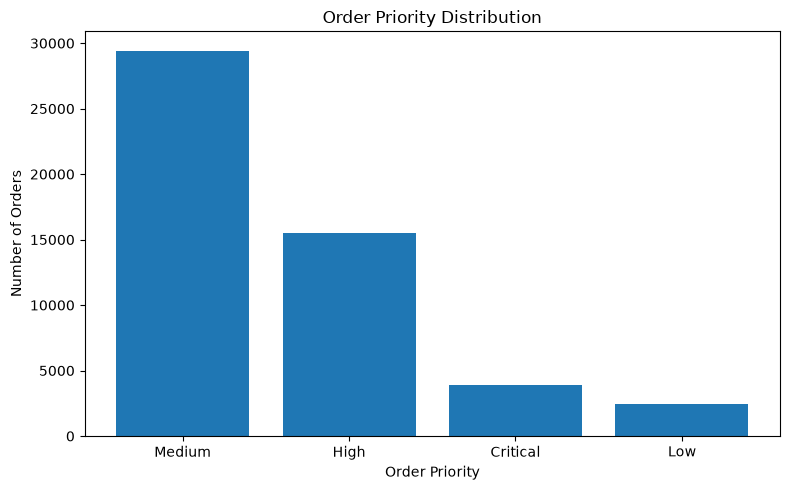

In [ ]:
### ORDER PRIORITY DISTRIBUTION 
priority_counts = df["Order Priority"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(priority_counts.index, priority_counts.values)

plt.title("Order Priority Distribution")
plt.xlabel("Order Priority")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

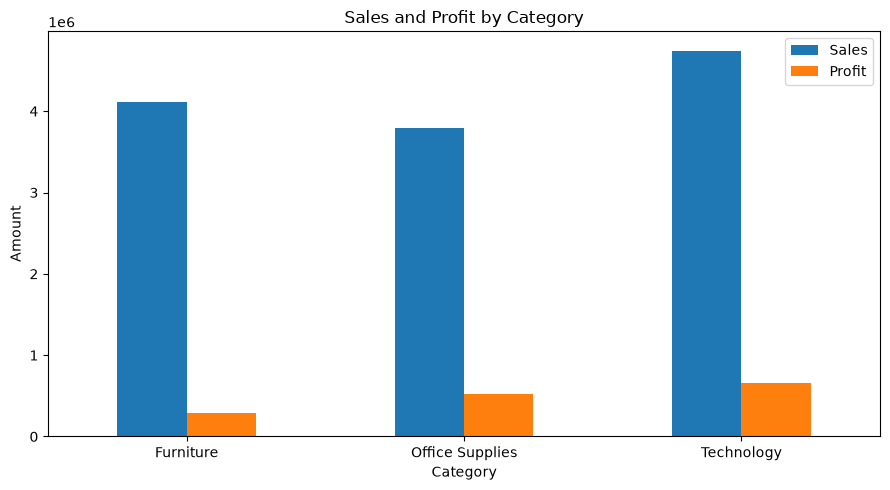

In [ ]:
###SALES AND PROFIT BY CATEGORY- BAR CHART 
category_data = df.groupby("Category")[["Sales", "Profit"]].sum()

category_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])

plt.tight_layout()
plt.show()

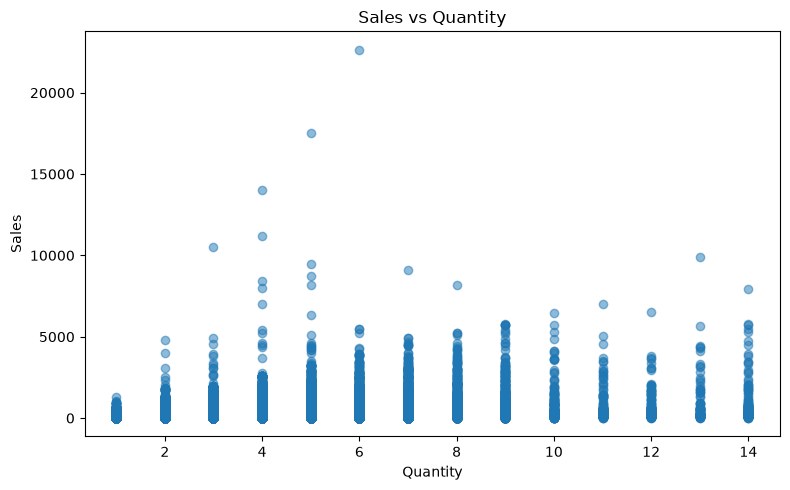

In [ ]:
###SALES VS QUANTITY - SCATTER PLOT
plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Sales"], alpha=0.5)

plt.title("Sales vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

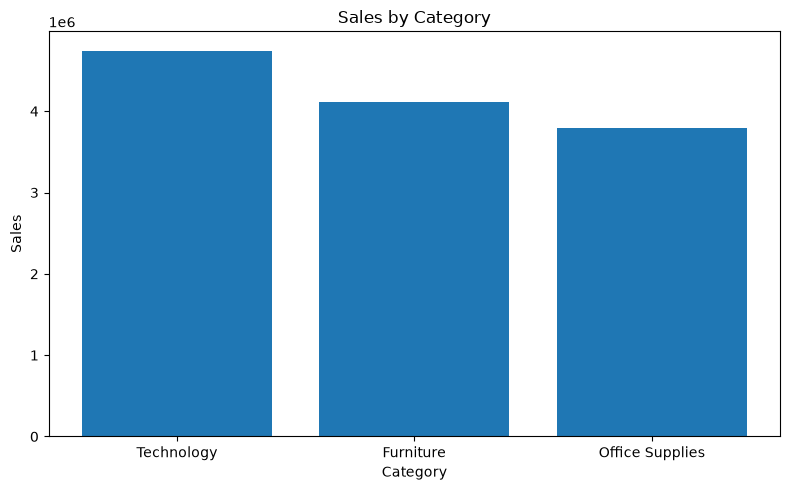

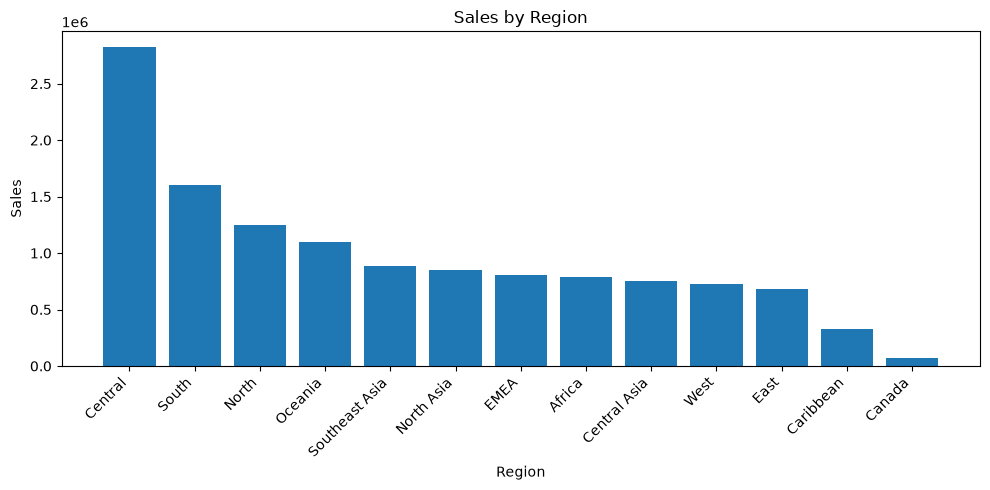

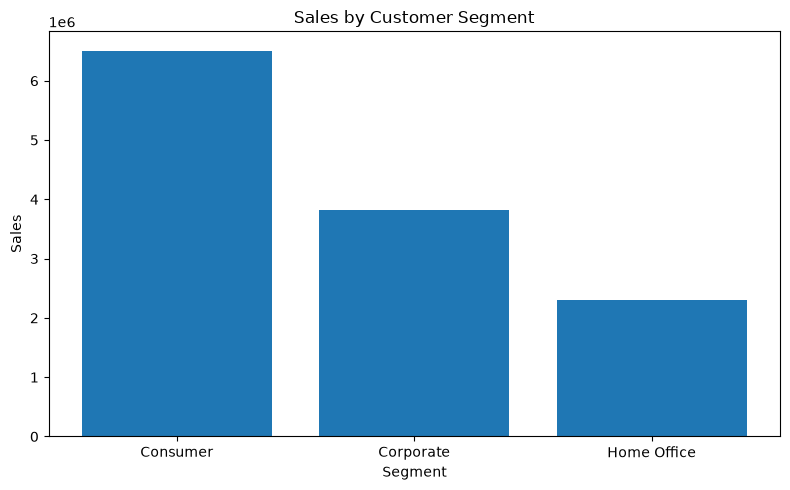

In [ ]:
###FINAL VISUALIZATION SUMMARY
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

# Category Sales
plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Region Sales
plt.figure(figsize=(10, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Segment Sales
plt.figure(figsize=(8, 5))
plt.bar(segment_sales.index, segment_sales.values)
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()